In [1]:
import numpy as np
import pandas as pd
import arff
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from autofeat import AutoFeatRegressor 
import featuretools as ft


In [2]:
with open("../data/german-credit-R.arff", "r") as file:
    data = arff.load(file)
df = pd.DataFrame(data["data"], columns=[attr[0] for attr in data["attributes"]])
 

In [3]:
cat_cols = ["Sex", "Housing", "Saving accounts", "Checking account", "Purpose","Risk"]
for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

In [4]:
df.isna().sum()

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

In [5]:
from sklearn.metrics import accuracy_score, precision_score

def evaluate_classifier(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary') 
    confusion_mx = confusion_matrix(y_test, y_pred)
    
    return accuracy, precision,confusion_mx

In [6]:
X = df.drop(columns=["Risk"])  
y = df["Risk"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)



In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

logreg = LogisticRegression()
nb = GaussianNB()
rf = RandomForestClassifier(random_state=42)

In [11]:
logreg_accuracy, logreg_precision,logreg_confusion_mx = evaluate_classifier(logreg, X_train, y_train, X_test, y_test)
nb_accuracy, nb_precision,nb_confusion_mx = evaluate_classifier(nb, X_train, y_train, X_test, y_test)
rf_accuracy, rf_precision,rf_confusion_mx = evaluate_classifier(rf, X_train, y_train, X_test, y_test)

print(f"Logistic Regression Accuracy: {logreg_accuracy:.4f}, Precision: {logreg_precision:.4f}")
print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}, Precision: {nb_precision:.4f}")
print(f"Random Forest Accuracy: {rf_accuracy:.4f}, Precision: {rf_precision:.4f}\n\n")

print(f"Logistic Regression Confusion Matrix:\n{logreg_confusion_mx}")
print(f"Naive Bayes Confusion Matrix:\n{nb_confusion_mx}")
print(f"Random Forest Confusion Matrix:\n{rf_confusion_mx}")

Logistic Regression Accuracy: 0.7550, Precision: 0.7771
Naive Bayes Accuracy: 0.7100, Precision: 0.7610
Random Forest Accuracy: 0.7700, Precision: 0.7950


Logistic Regression Confusion Matrix:
[[ 22  37]
 [ 12 129]]
Naive Bayes Confusion Matrix:
[[ 21  38]
 [ 20 121]]
Random Forest Confusion Matrix:
[[ 26  33]
 [ 13 128]]


In [12]:
#https://medium.com/@boukamchahamdi/autofeat-automating-feature-engineering-with-python-f22ec23265a9
af = AutoFeatRegressor( feateng_steps=2,n_jobs=-1)  

X_train_af = af.fit_transform(X_train, y_train)
X_test_af = af.transform(X_test)
X_train_af.head()

c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\autofeat\featsel.py:270: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  if np.max(np.abs(correlations[c].ravel()[:i])) < 0.9:
c:\Users\H P\git\projetTutoreAutoFE\venv\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,x000,x001,x002,x003,x004,x005,x006,x007,x008,x004*exp(x007),x005/x002,Abs(x006)
0,2.414647,0.670280,0.146949,-0.133710,-0.699707,-1.254566,1.263499,3.243815,-1.455632,-17.934414,-8.537412,1.263499
1,-0.223927,0.670280,0.146949,1.749535,-0.699707,0.336513,-0.337522,0.008048,0.061705,-0.705361,2.289997,0.337522
2,1.271265,0.670280,0.146949,1.749535,0.566731,1.132053,-0.721384,-1.236478,-0.949853,0.164582,7.703701,0.721384
3,-0.575737,-1.491914,0.146949,-0.133710,1.833169,1.132053,0.613804,0.008048,-0.949853,1.847982,7.703701,0.613804
4,-1.279356,-1.491914,0.146949,-0.133710,1.833169,1.132053,-0.845439,-0.738668,1.073263,0.875797,7.703701,0.845439


In [13]:
print(f"Nombre de nouvelles features créées : {X_train_af.shape[1] - X_train.shape[1]}")

Nombre de nouvelles features créées : 3


In [14]:
acc_logreg_af, prec_logreg_af,confusion_mx_logreg_af = evaluate_classifier(logreg, X_train_af, y_train, X_test_af, y_test)
acc_nb_af, prec_nb_af,confusion_mx_nb_af = evaluate_classifier(nb, X_train_af, y_train, X_test_af, y_test)
acc_rf_af, prec_rf_af,confusion_mx_rf_af = evaluate_classifier(rf, X_train_af, y_train, X_test_af, y_test)

print(f"Logistic Regression Accuracy with AutoFeat: {acc_logreg_af:.2f}, Precision: {prec_logreg_af:.2f}")
print(f"Naive Bayes Accuracy with AutoFeat: {acc_nb_af:.2f}, Precision: {prec_nb_af:.2f}")
print(f"Random Forest Accuracy with AutoFeat: {acc_rf_af:.2f}, Precision: {prec_rf_af:.2f}\n\n")

print(f"Logistic Regression Confusion Matrix with AutoFeat:\n{confusion_mx_logreg_af}")
print(f"Naive Bayes Confusion Matrix with AutoFeat:\n{confusion_mx_nb_af}")
print(f"Random Forest Confusion Matrix with AutoFeat:\n{confusion_mx_rf_af}")

Logistic Regression Accuracy with AutoFeat: 0.76, Precision: 0.78
Naive Bayes Accuracy with AutoFeat: 0.71, Precision: 0.78
Random Forest Accuracy with AutoFeat: 0.78, Precision: 0.80


Logistic Regression Confusion Matrix with AutoFeat:
[[ 21  38]
 [ 10 131]]
Naive Bayes Confusion Matrix with AutoFeat:
[[ 27  32]
 [ 26 115]]
Random Forest Confusion Matrix with AutoFeat:
[[ 28  31]
 [ 14 127]]


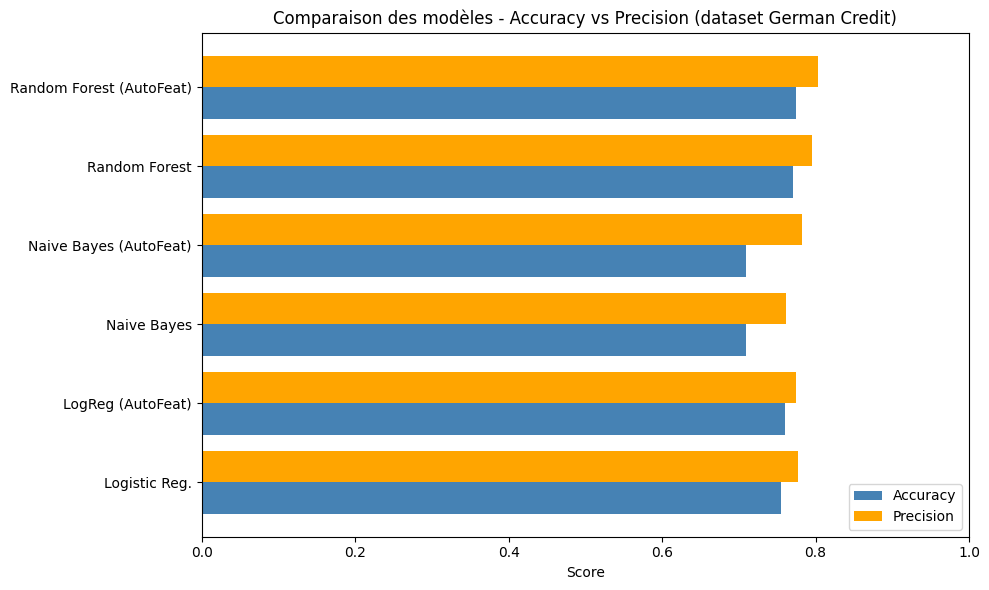

In [17]:
import matplotlib.pyplot as plt
import numpy as np


model_labels = [
    "Logistic Reg.", "LogReg (AutoFeat)", "Naive Bayes","Naive Bayes (AutoFeat)", "Random Forest",
     "Random Forest (AutoFeat)"
]


accuracy_values = [logreg_accuracy,acc_logreg_af , nb_accuracy, acc_nb_af, rf_accuracy, acc_rf_af]
precision_values = [logreg_precision, prec_logreg_af, nb_precision,prec_nb_af, rf_precision , prec_rf_af]

y = np.arange(len(model_labels))
bar_height = 0.4

fig, ax = plt.subplots(figsize=(10, 6))


ax.barh(y - bar_height/2, accuracy_values, height=bar_height, color='steelblue', label='Accuracy')


ax.barh(y + bar_height/2, precision_values, height=bar_height, color='orange', label='Precision')

# Axe Y
ax.set_yticks(y)
ax.set_yticklabels(model_labels)
ax.set_xlim(0, 1)
ax.set_xlabel("Score")
ax.set_title("Comparaison des modèles - Accuracy vs Precision (dataset German Credit)")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()


In [15]:
#https://www.analyticsvidhya.com/blog/2018/08/guide-automated-feature-engineering-featuretools-python/
#https://ranasinghiitkgp.medium.com/feature-engineering-using-featuretools-with-code-10f8c83e5f68
#Avec featuretools

